# Fold-wise Training Analysis & Modality Weight Contribution
Visualizes per-fold training curves (accuracy, loss, AUC, LR) and modality weight pie charts.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.dpi': 130,
})

## 1. Load Data

In [2]:
# ── Configure paths ──────────────────────────────────────────────────────────
# If running from the same directory as the JSON files, keep prefix = ''
# Otherwise set it to the folder path, e.g. '/content/data/'
HIST_PREFIX = r'E:\4thYearProjectCoding\outputs\logs\\' 
  # <-- edit if needed
WT_PREFIX   = r'E:\4thYearProjectCoding\outputs\results\\'
NUM_FOLDS = 5

histories = {}
mod_weights = {}

for fold in range(NUM_FOLDS):
    hist_path = f"{HIST_PREFIX}fold{fold}_history.json"
    wt_path   = f"{WT_PREFIX}fold{fold}_modality_weights.json"

    with open(hist_path) as f:
        histories[fold] = json.load(f)
    with open(wt_path) as f:
        mod_weights[fold] = json.load(f)

print("Loaded folds:", list(histories.keys()))
for fold, wt in mod_weights.items():
    print(f"  Fold {fold} — epochs: {len(histories[fold])}, weights: {wt['weights']}")

Loaded folds: [0, 1, 2, 3, 4]
  Fold 0 — epochs: 22, weights: {'CT image (CNN)': 0.3366, 'Clinical text': 0.3346, 'Lab numerics': 0.3288}
  Fold 1 — epochs: 47, weights: {'CT image (CNN)': 0.3419, 'Clinical text': 0.334, 'Lab numerics': 0.3241}
  Fold 2 — epochs: 63, weights: {'CT image (CNN)': 0.3423, 'Clinical text': 0.3351, 'Lab numerics': 0.3225}
  Fold 3 — epochs: 16, weights: {'CT image (CNN)': 0.3361, 'Clinical text': 0.3343, 'Lab numerics': 0.3295}
  Fold 4 — epochs: 56, weights: {'CT image (CNN)': 0.3422, 'Clinical text': 0.335, 'Lab numerics': 0.3228}


## 2. Helper — Extract Metric Arrays

In [3]:
def extract(history, key):
    """Return a numpy array of a metric across all epochs."""
    return np.array([e[key] for e in history])

COLORS = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']
MODALITY_COLORS = ['#E63946', '#457B9D', '#2A9D8F']  # CNN, Text, Numeric

## 3. Per-Fold Training Curves (individual)

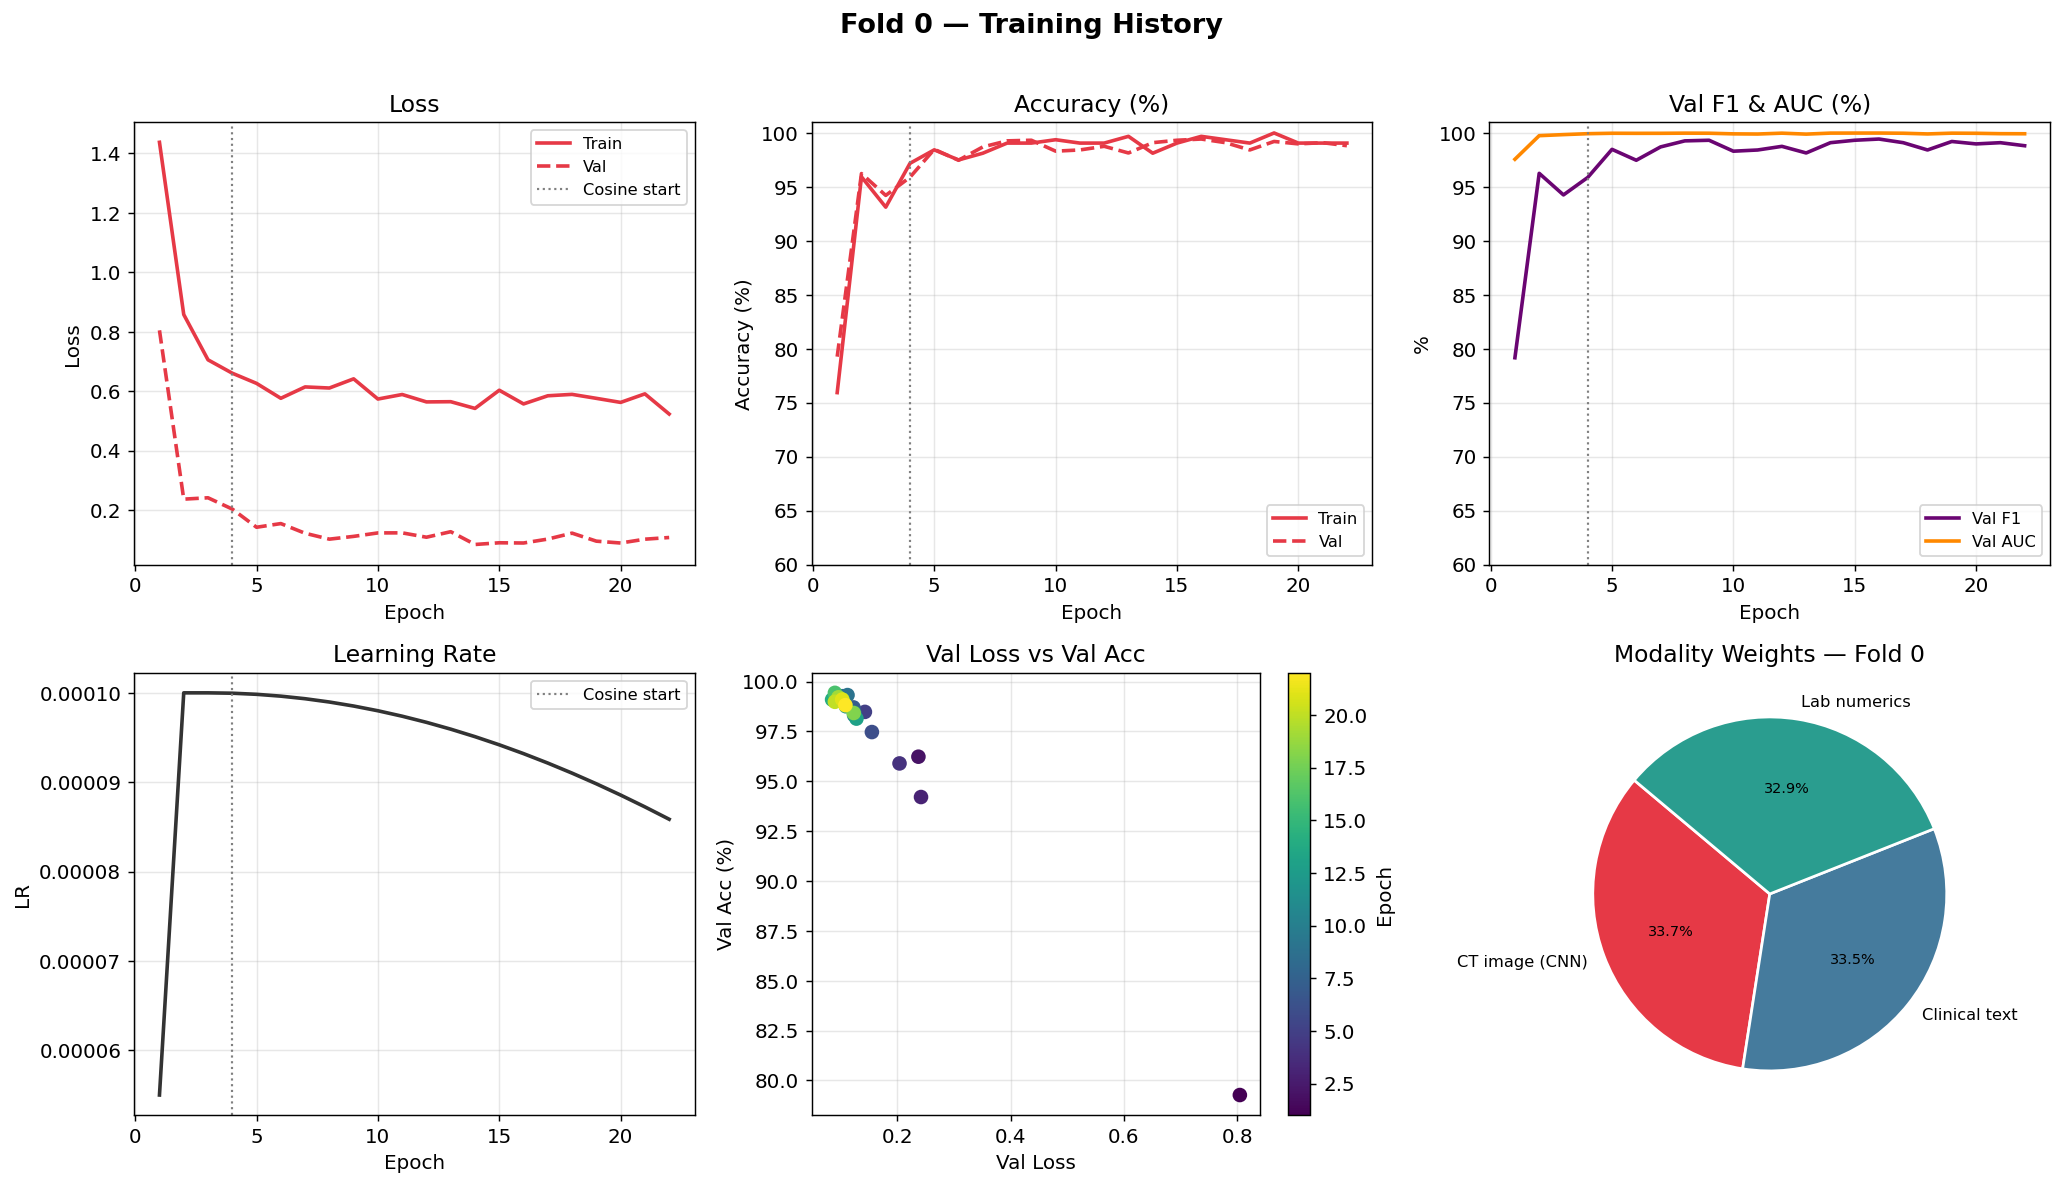

✓ Saved fold0_analysis.png


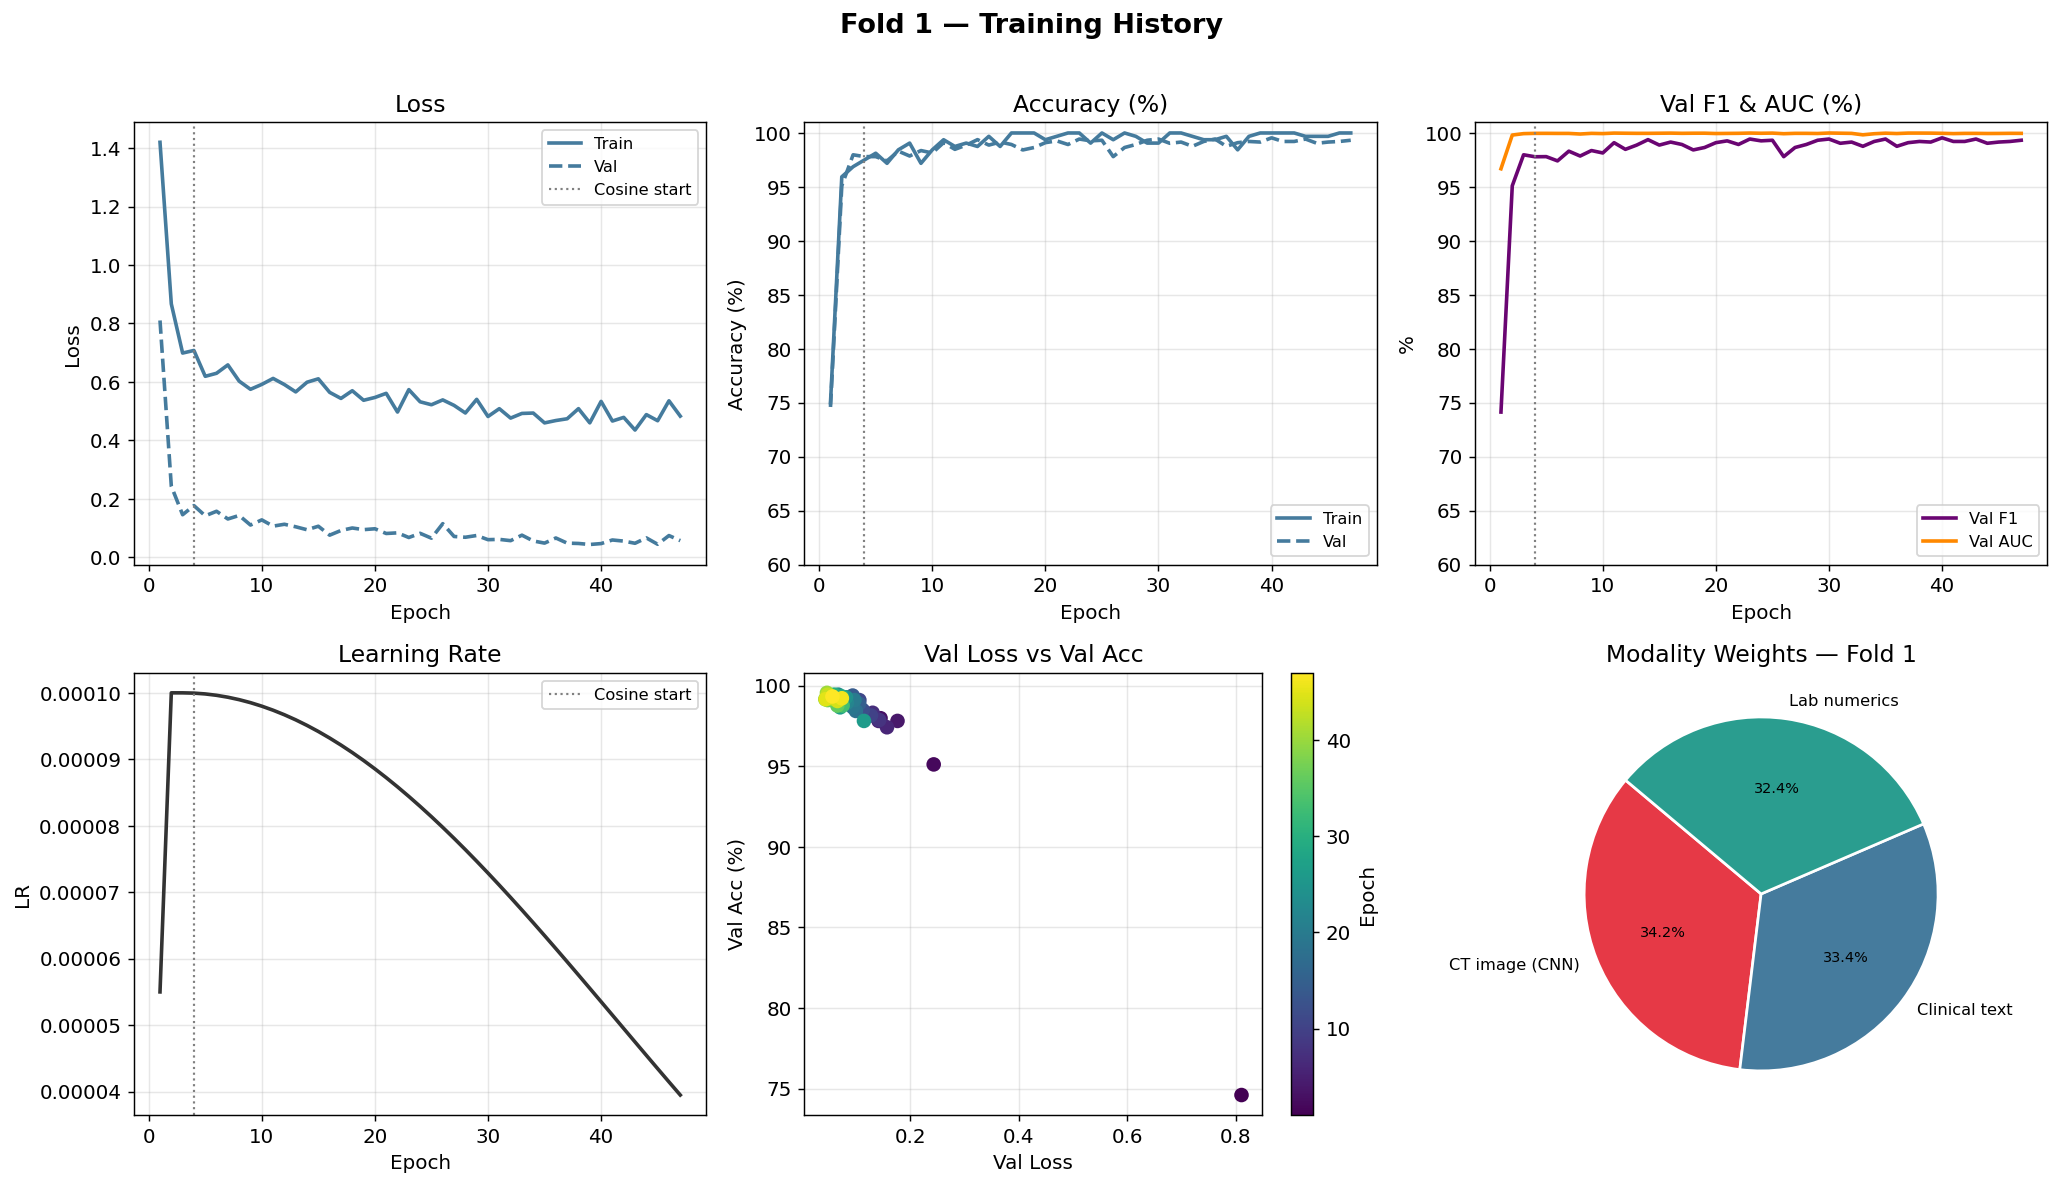

✓ Saved fold1_analysis.png


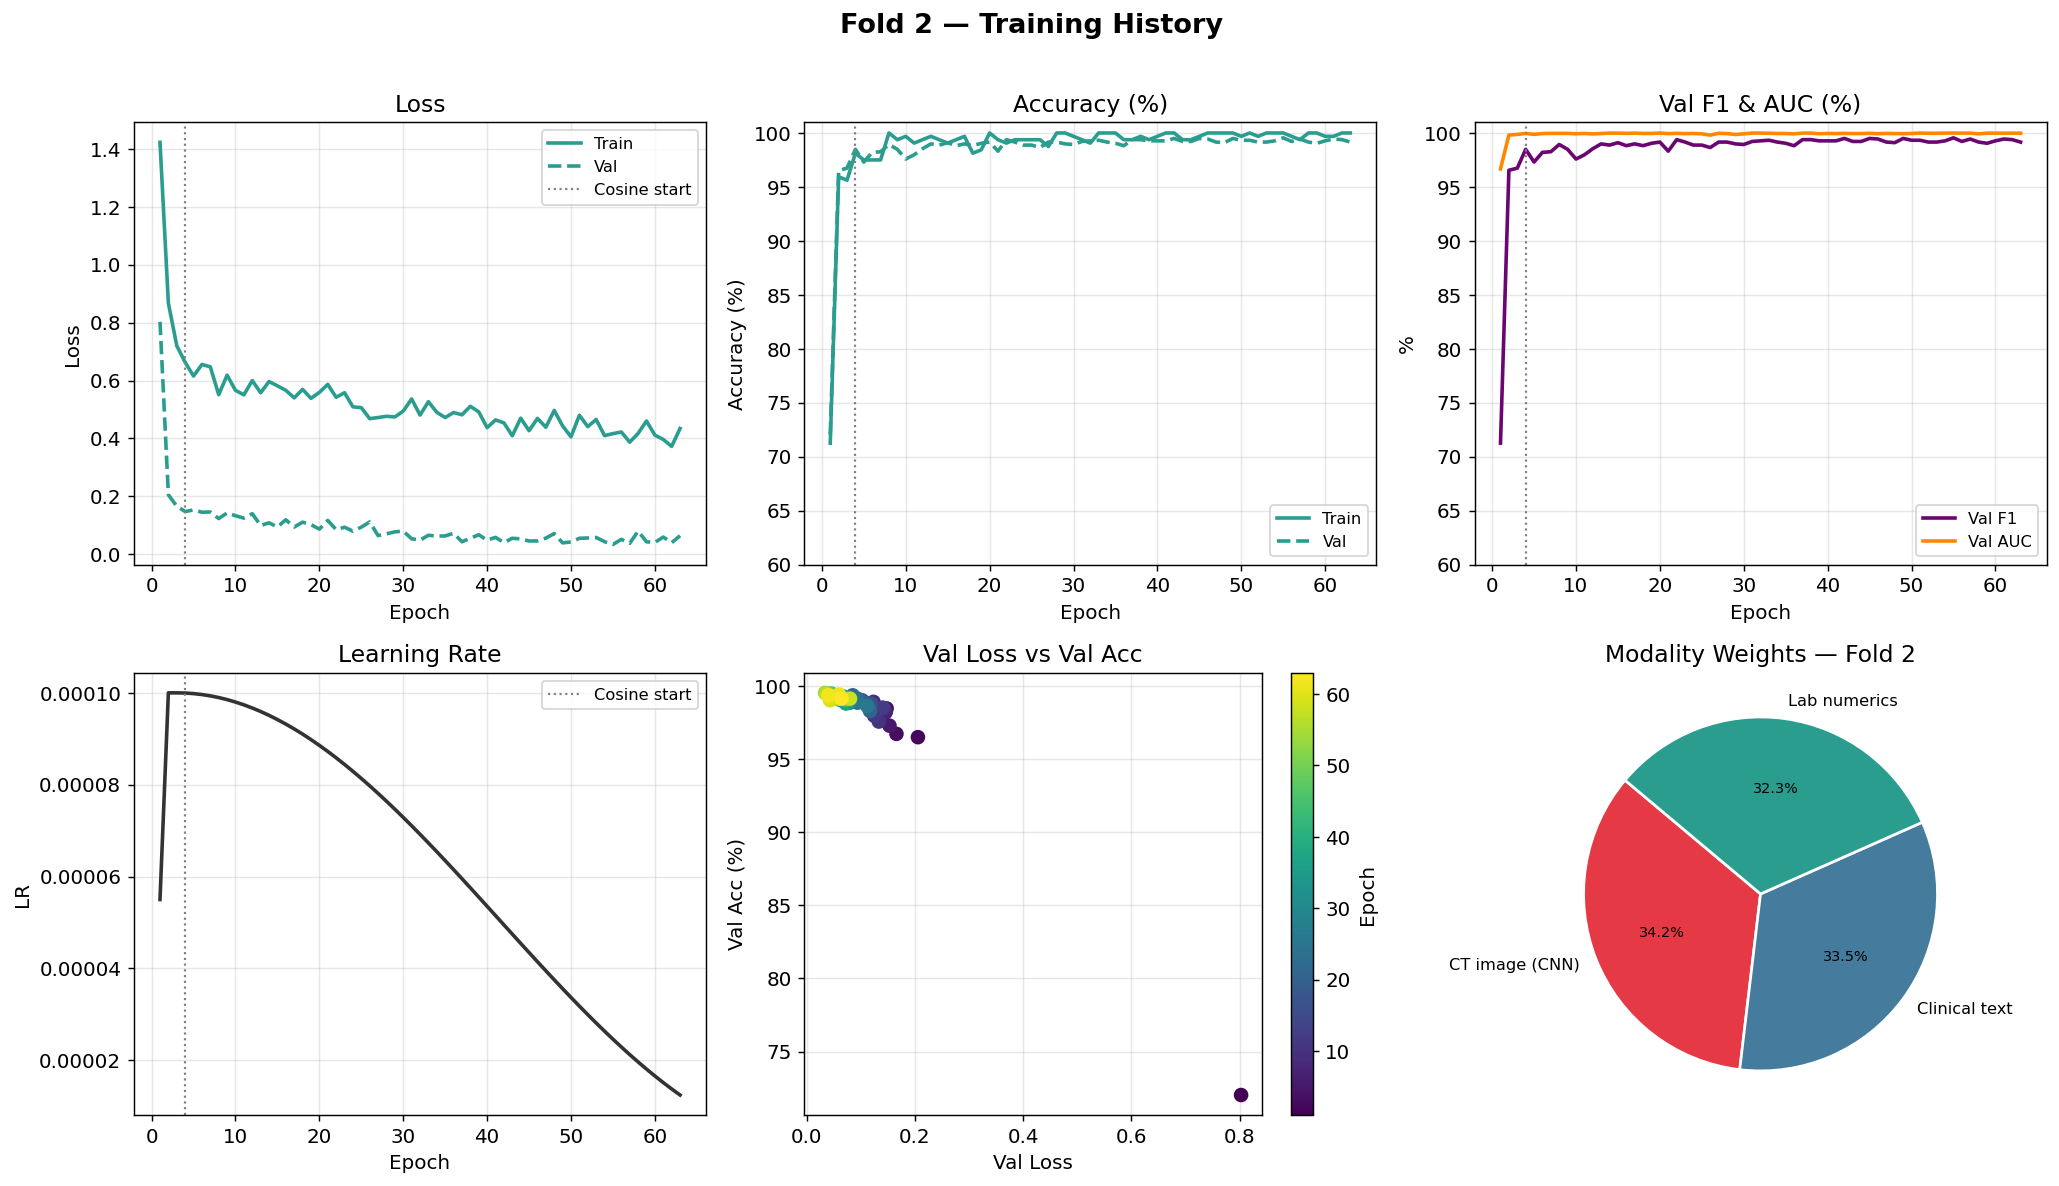

✓ Saved fold2_analysis.png


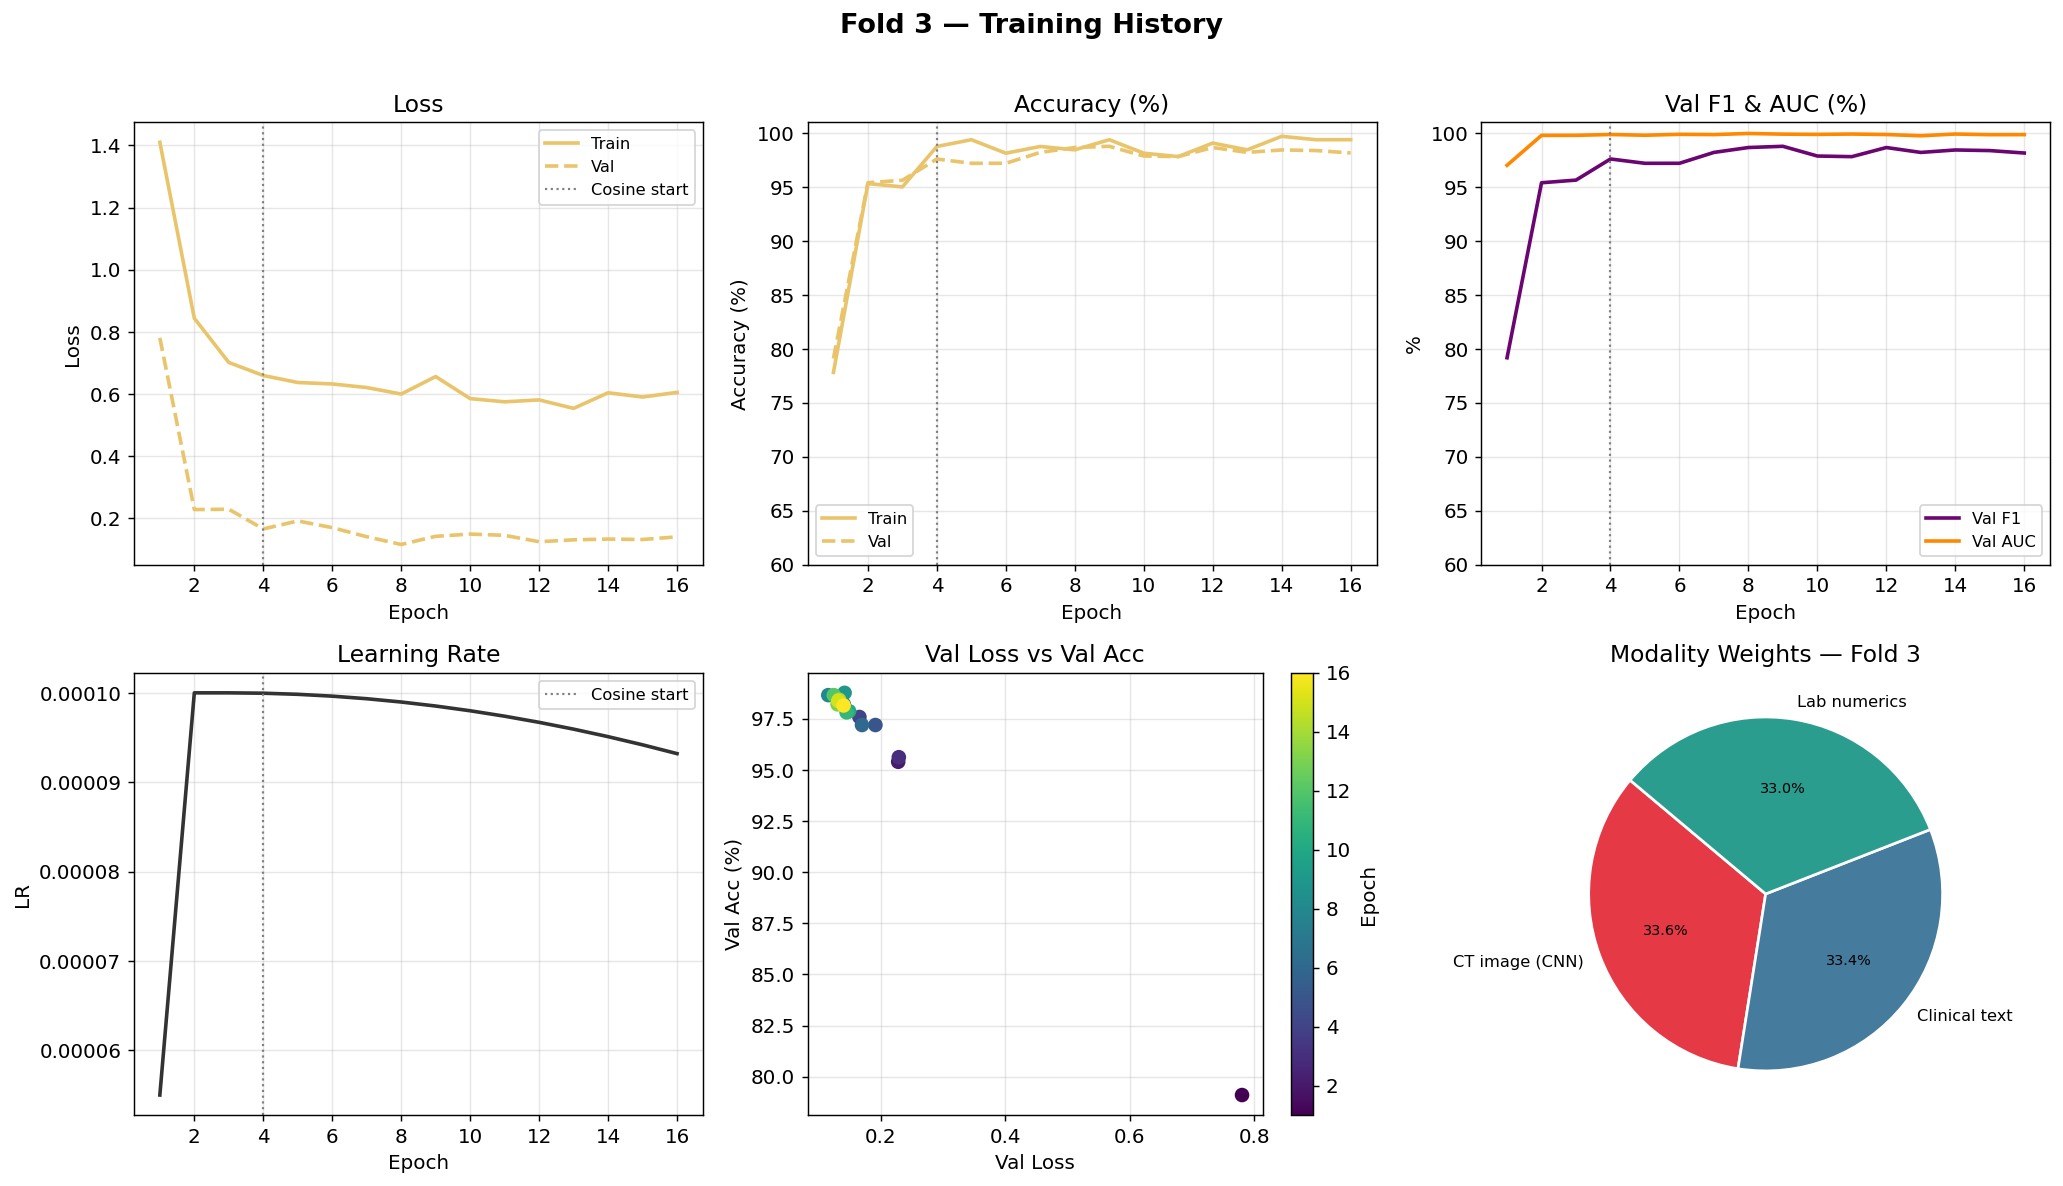

✓ Saved fold3_analysis.png


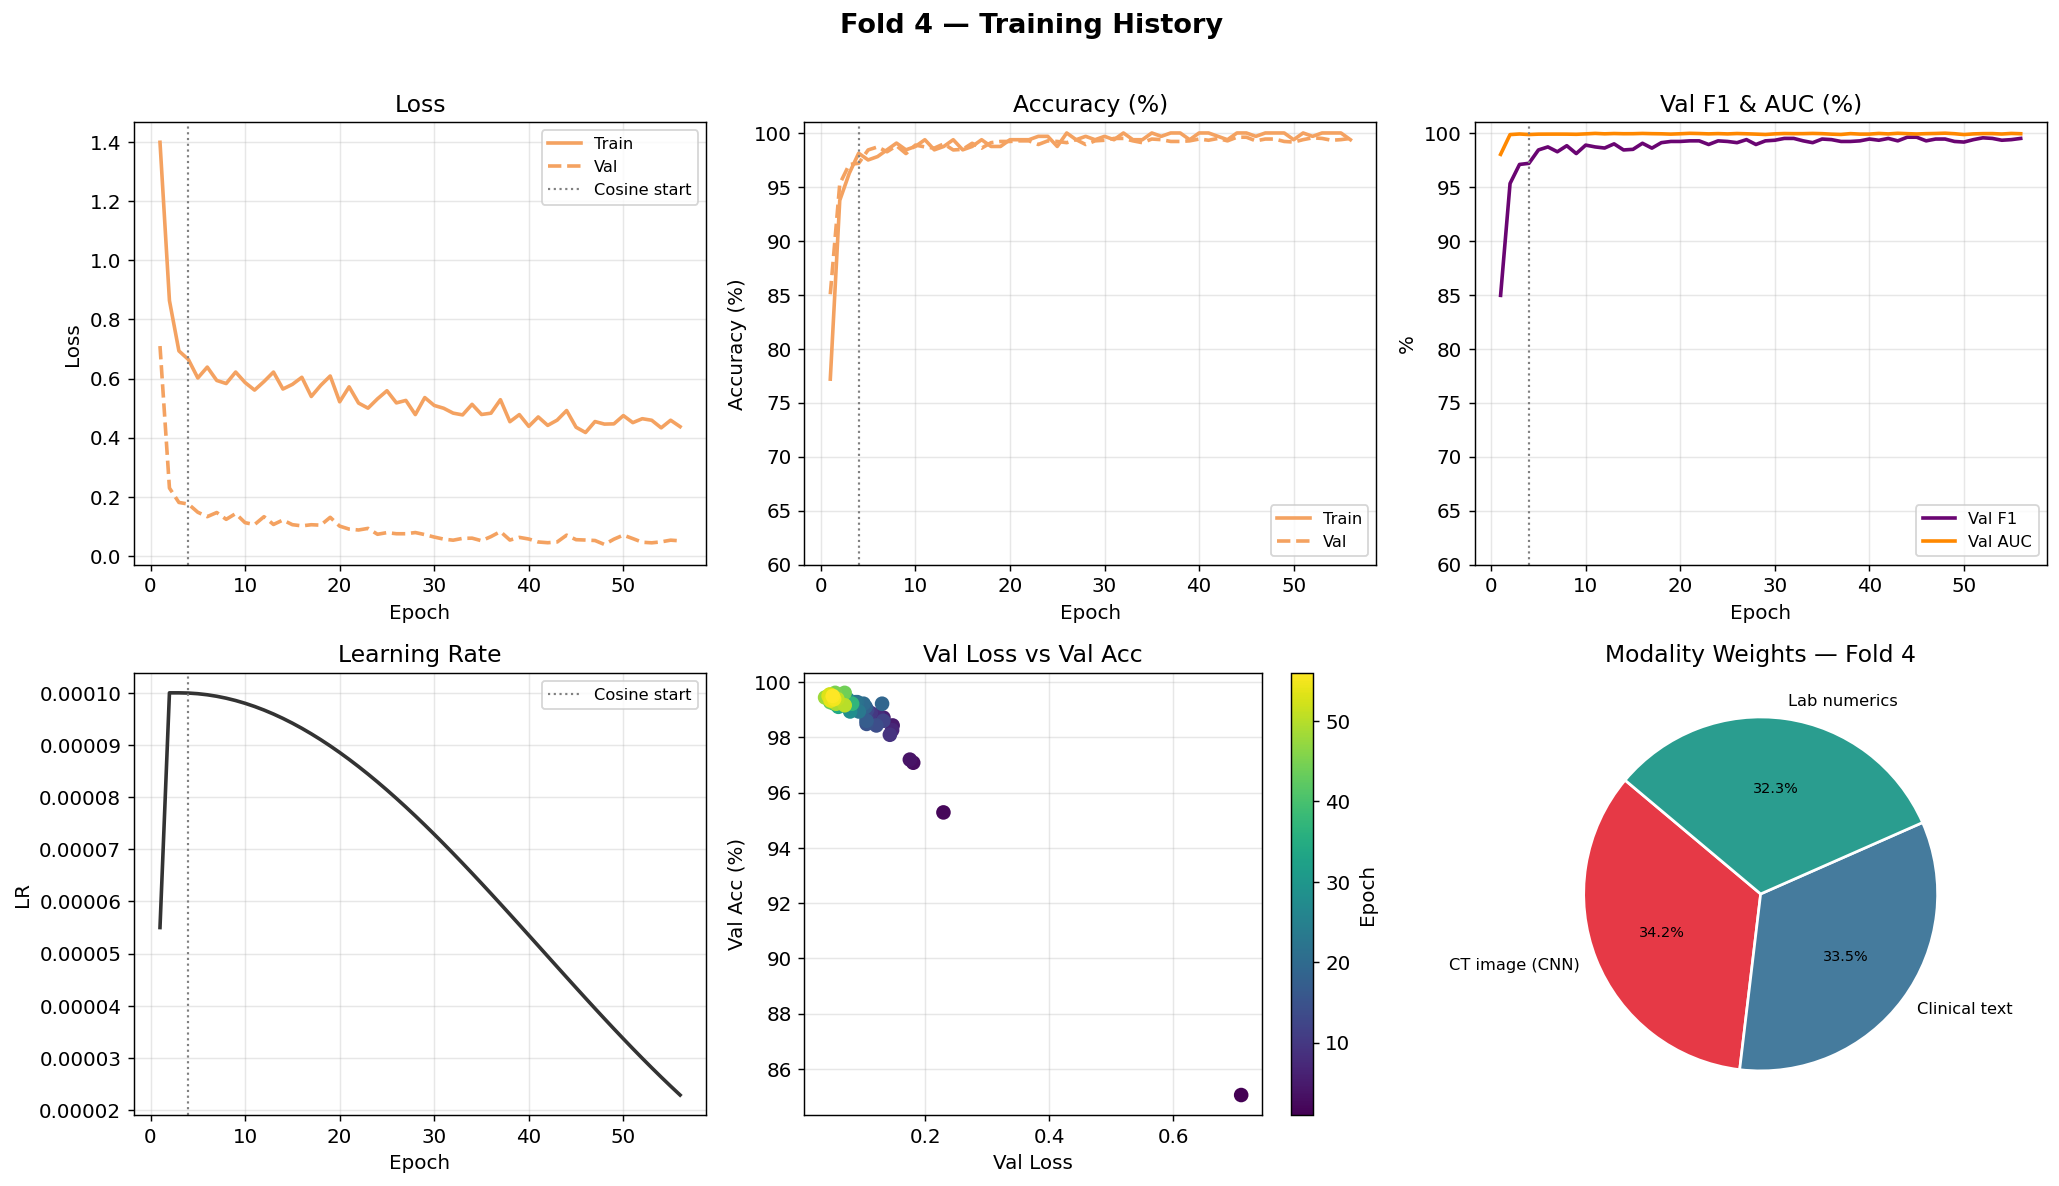

✓ Saved fold4_analysis.png


In [4]:
for fold in range(NUM_FOLDS):
    hist = histories[fold]
    epochs     = extract(hist, 'epoch')
    train_loss = extract(hist, 'train_loss')
    val_loss   = extract(hist, 'val_loss')
    train_acc  = extract(hist, 'train_acc')
    val_acc    = extract(hist, 'val_acc')
    val_f1     = extract(hist, 'val_f1')
    val_auc    = extract(hist, 'val_auc')
    lr         = extract(hist, 'lr')
    phases     = [e['phase'] for e in hist]

    # Mark warmup / cosine boundary
    warmup_end = next((i for i, p in enumerate(phases) if p == 'cosine'), len(phases))

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'Fold {fold} — Training History', fontsize=15, fontweight='bold', y=1.01)

    ax = axes[0, 0]
    ax.plot(epochs, train_loss, color=COLORS[fold], lw=2, label='Train')
    ax.plot(epochs, val_loss,   color=COLORS[fold], lw=2, ls='--', label='Val')
    if warmup_end < len(epochs):
        ax.axvline(epochs[warmup_end], color='grey', ls=':', lw=1.2, label='Cosine start')
    ax.set_title('Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    ax.plot(epochs, train_acc * 100, color=COLORS[fold], lw=2, label='Train')
    ax.plot(epochs, val_acc   * 100, color=COLORS[fold], lw=2, ls='--', label='Val')
    if warmup_end < len(epochs):
        ax.axvline(epochs[warmup_end], color='grey', ls=':', lw=1.2)
    ax.set_title('Accuracy (%)'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(60, 101); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 2]
    ax.plot(epochs, val_f1  * 100, color='#6A0572', lw=2, label='Val F1')
    ax.plot(epochs, val_auc * 100, color='#FF8800', lw=2, label='Val AUC')
    if warmup_end < len(epochs):
        ax.axvline(epochs[warmup_end], color='grey', ls=':', lw=1.2)
    ax.set_title('Val F1 & AUC (%)'); ax.set_xlabel('Epoch'); ax.set_ylabel('%')
    ax.set_ylim(60, 101); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(epochs, lr, color='#333333', lw=2)
    if warmup_end < len(epochs):
        ax.axvline(epochs[warmup_end], color='grey', ls=':', lw=1.2, label='Cosine start')
        ax.legend()
    ax.set_title('Learning Rate'); ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
    ax.grid(alpha=0.3)

    # Val loss vs Val acc scatter
    ax = axes[1, 1]
    sc = ax.scatter(val_loss, val_acc * 100, c=epochs, cmap='viridis', s=50, zorder=3)
    plt.colorbar(sc, ax=ax, label='Epoch')
    ax.set_title('Val Loss vs Val Acc'); ax.set_xlabel('Val Loss'); ax.set_ylabel('Val Acc (%)')
    ax.grid(alpha=0.3)

    # Modality weight pie
    ax = axes[1, 2]
    wt = mod_weights[fold]['weights']
    labels = list(wt.keys())
    sizes  = list(wt.values())
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=MODALITY_COLORS,
        autopct='%1.1f%%', startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops=dict(fontsize=9)
    )
    for at in autotexts:
        at.set_fontsize(8)
    ax.set_title(f'Modality Weights — Fold {fold}')

    plt.tight_layout()
    plt.savefig(f'fold{fold}_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved fold{fold}_analysis.png")

## 4. All-Fold Comparison: Train & Val Curves

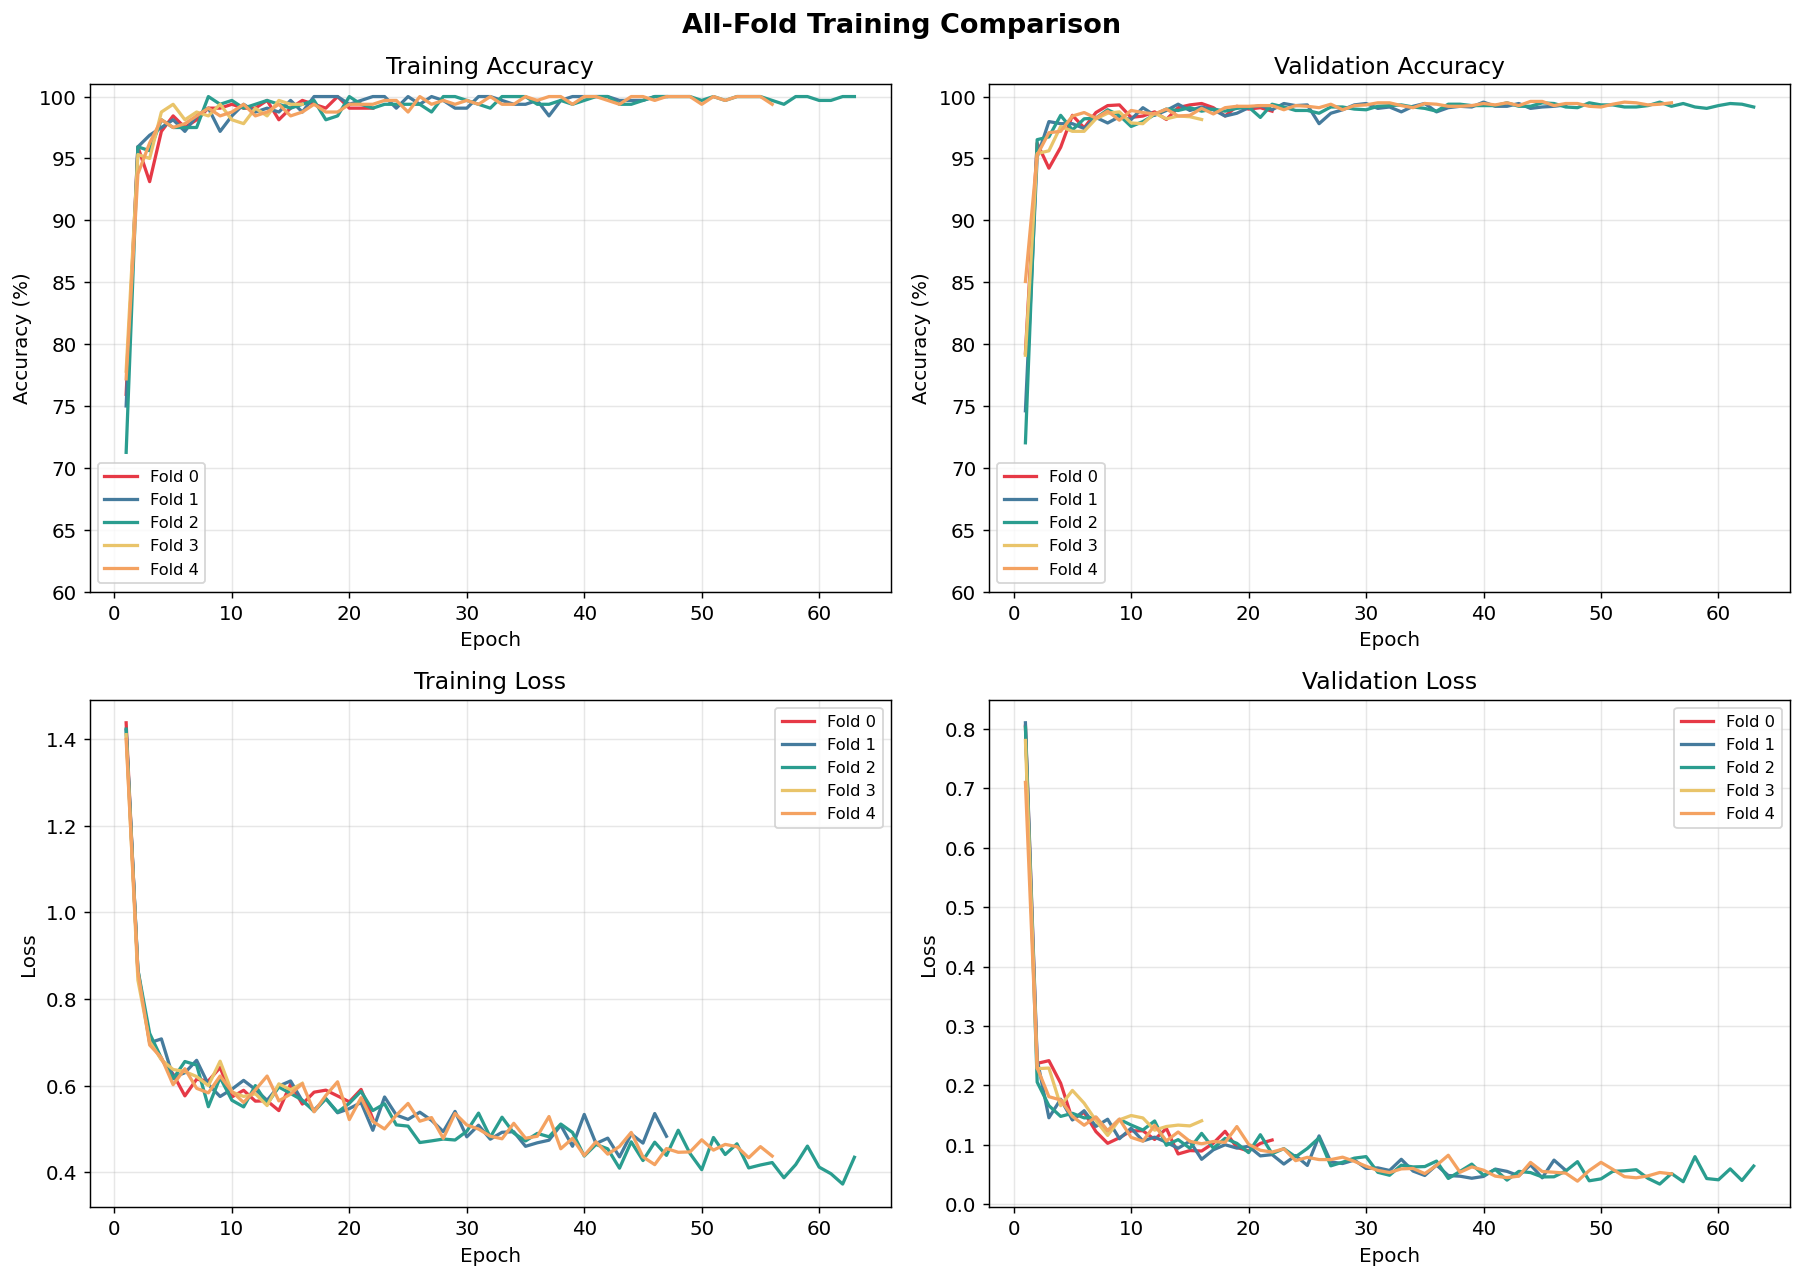

✓ Saved all_folds_comparison.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('All-Fold Training Comparison', fontsize=15, fontweight='bold')

metrics = [
    ('train_acc', 'val_acc',   'Training Accuracy',   'Validation Accuracy',   'Accuracy (%)', True),
    ('train_loss','val_loss',  'Training Loss',        'Validation Loss',        'Loss',         False),
]

for row, (tr_key, vl_key, tr_title, vl_title, ylabel, pct) in enumerate(metrics):
    for col, (key, title) in enumerate([(tr_key, tr_title), (vl_key, vl_title)]):
        ax = axes[row, col]
        for fold in range(NUM_FOLDS):
            vals = extract(histories[fold], key)
            ep   = extract(histories[fold], 'epoch')
            if pct:
                vals = vals * 100
            ax.plot(ep, vals, color=COLORS[fold], lw=1.8, label=f'Fold {fold}')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)
        if pct:
            ax.set_ylim(60, 101)

plt.tight_layout()
plt.savefig('all_folds_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Saved all_folds_comparison.png")

## 5. All-Fold AUC & F1 Comparison

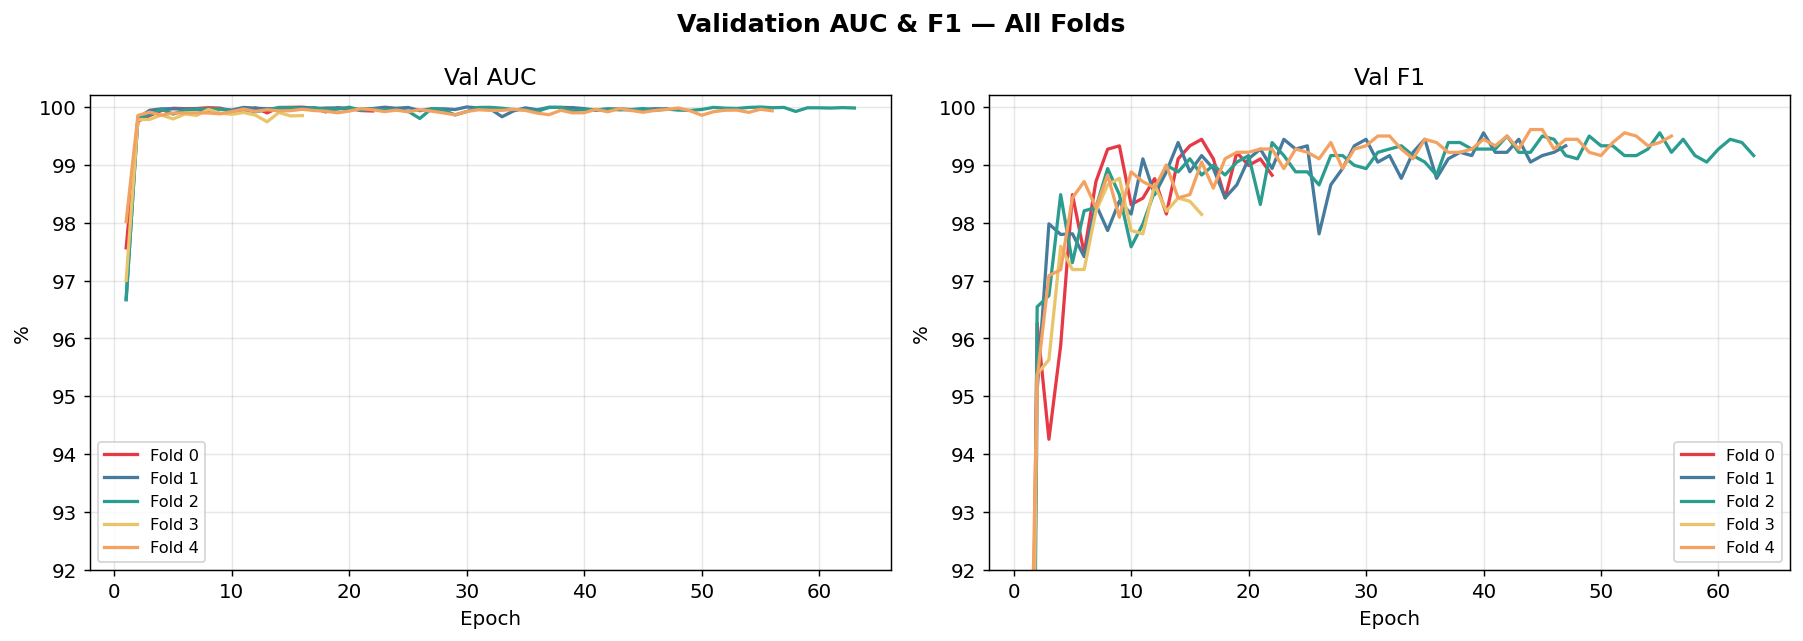

✓ Saved all_folds_auc_f1.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validation AUC & F1 — All Folds', fontsize=14, fontweight='bold')

for ax, (key, title) in zip(axes, [('val_auc','Val AUC'), ('val_f1','Val F1')]):
    for fold in range(NUM_FOLDS):
        vals = extract(histories[fold], key) * 100
        ep   = extract(histories[fold], 'epoch')
        ax.plot(ep, vals, color=COLORS[fold], lw=1.8, label=f'Fold {fold}')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('%')
    ax.set_ylim(92, 100.2); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('all_folds_auc_f1.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Saved all_folds_auc_f1.png")

## 6. Modality Weight Comparison Across Folds

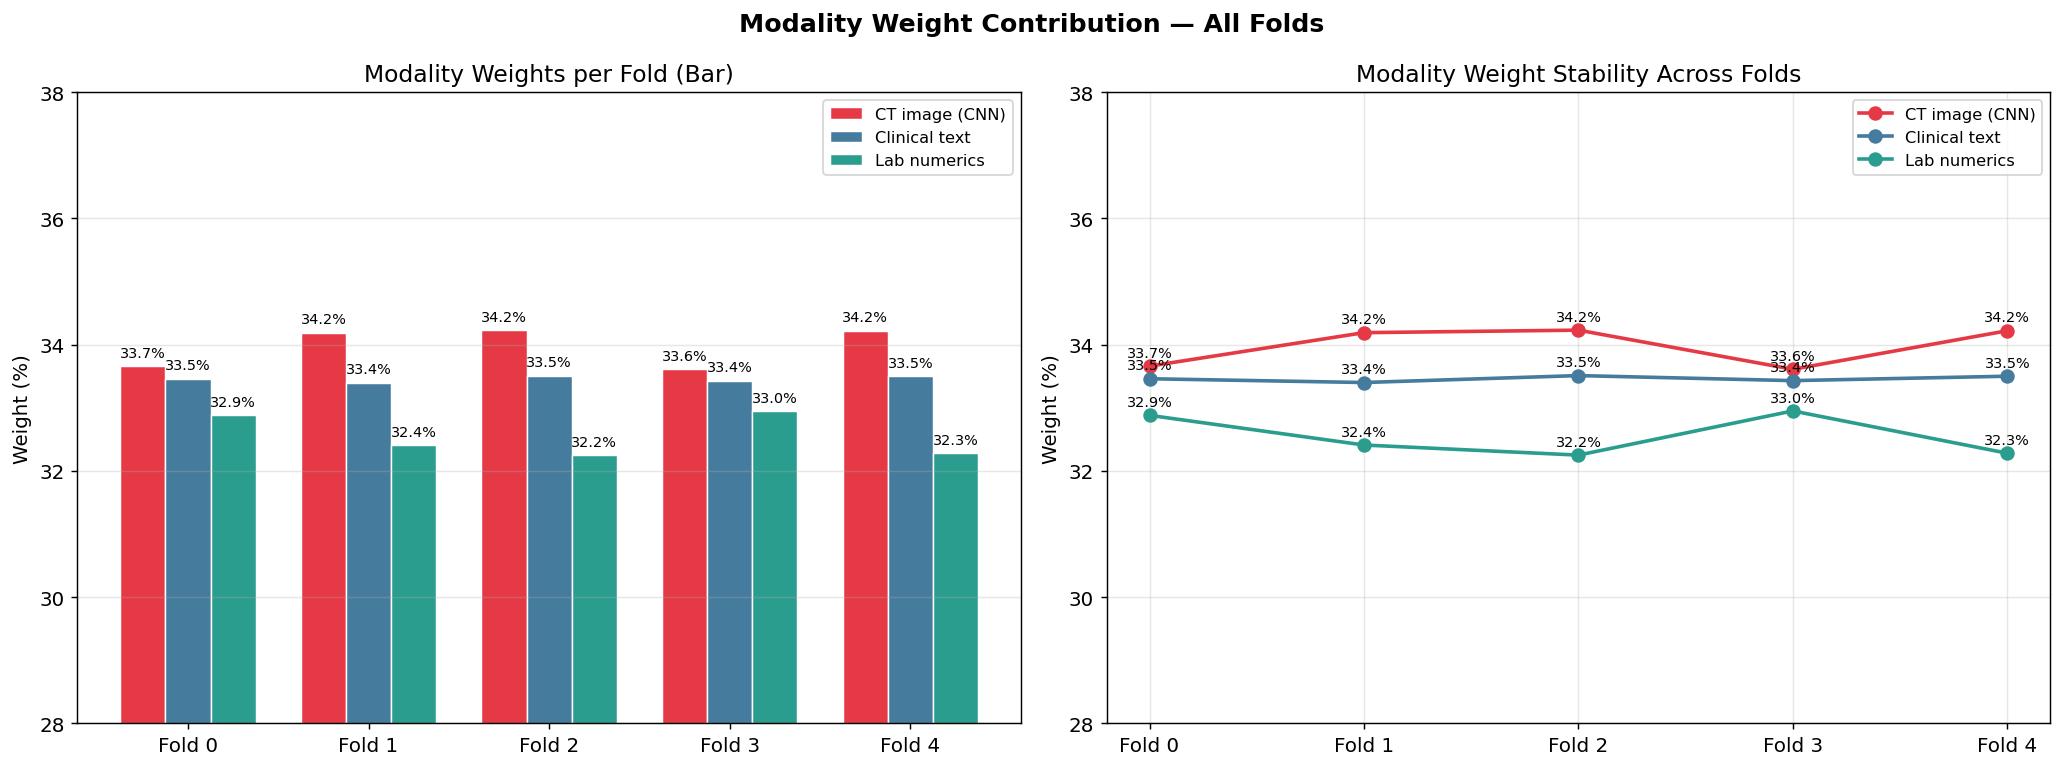

✓ Saved modality_weights_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Modality Weight Contribution — All Folds', fontsize=14, fontweight='bold')

# ── Left: Grouped bar chart ──────────────────────────────────────────────────
ax = axes[0]
modalities = list(mod_weights[0]['weights'].keys())
x = np.arange(NUM_FOLDS)
width = 0.25

for i, (mod, color) in enumerate(zip(modalities, MODALITY_COLORS)):
    vals = [mod_weights[f]['weights'][mod] * 100 for f in range(NUM_FOLDS)]
    bars = ax.bar(x + i * width, vals, width, label=mod, color=color, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {f}' for f in range(NUM_FOLDS)])
ax.set_ylabel('Weight (%)')
ax.set_title('Modality Weights per Fold (Bar)')
ax.set_ylim(28, 38)
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── Right: Line plot showing weight stability ────────────────────────────────
ax = axes[1]
for mod, color in zip(modalities, MODALITY_COLORS):
    vals = [mod_weights[f]['weights'][mod] * 100 for f in range(NUM_FOLDS)]
    ax.plot(range(NUM_FOLDS), vals, 'o-', color=color, lw=2, ms=7, label=mod)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(NUM_FOLDS))
ax.set_xticklabels([f'Fold {f}' for f in range(NUM_FOLDS)])
ax.set_ylabel('Weight (%)')
ax.set_title('Modality Weight Stability Across Folds')
ax.set_ylim(28, 38)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('modality_weights_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Saved modality_weights_comparison.png")

## 7. Modality Pie Charts — All Folds Side by Side

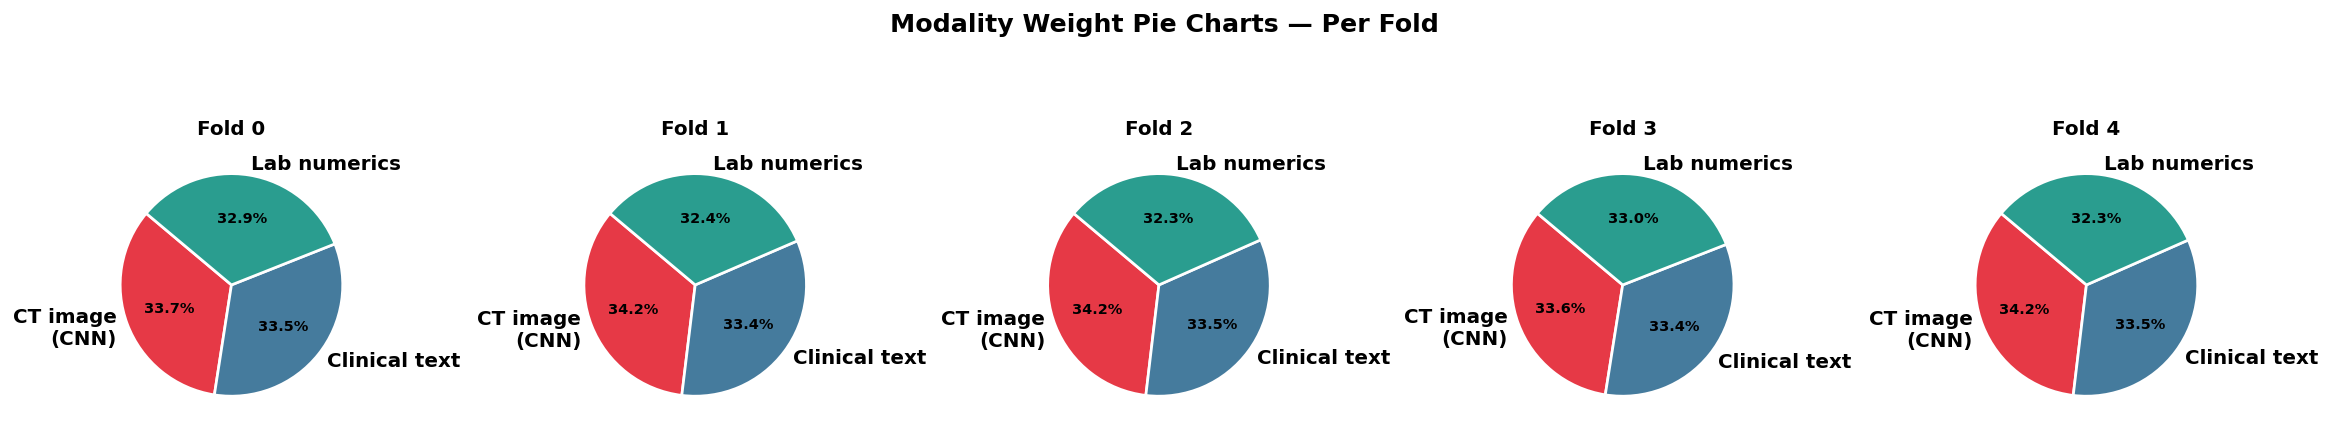

✓ Saved modality_pie_all_folds.png


In [8]:
fig, axes = plt.subplots(1, NUM_FOLDS, figsize=(18, 4))
fig.suptitle('Modality Weight Pie Charts — Per Fold', fontsize=14, fontweight='bold')

for fold, ax in zip(range(NUM_FOLDS), axes):
    wt     = mod_weights[fold]['weights']
    labels = [l.replace(' (CNN)', '\n(CNN)') for l in wt.keys()]
    sizes  = list(wt.values())
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=MODALITY_COLORS,
        autopct='%1.1f%%', startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops=dict(fontsize=11, fontweight='bold')
    )
    for at in autotexts:
        at.set_fontsize(8)
    ax.set_title(f'Fold {fold}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('modality_pie_all_folds.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Saved modality_pie_all_folds.png")

## 8. Summary Statistics Table

In [9]:
import pandas as pd

rows = []
for fold in range(NUM_FOLDS):
    hist = histories[fold]
    best_idx = np.argmax(extract(hist, 'val_auc'))
    best = hist[best_idx]
    wt = mod_weights[fold]['weights']
    rows.append({
        'Fold': fold,
        'Best Epoch': best['epoch'],
        'Total Epochs': len(hist),
        'Best Val Acc (%)': round(best['val_acc'] * 100, 2),
        'Best Val F1 (%)':  round(best['val_f1']  * 100, 2),
        'Best Val AUC (%)': round(best['val_auc'] * 100, 4),
        'Best Val Loss':    round(best['val_loss'], 5),
        'CNN Weight (%)':   round(wt['CT image (CNN)'] * 100, 2),
        'Text Weight (%)':  round(wt['Clinical text']  * 100, 2),
        'Numeric Weight (%)': round(wt['Lab numerics'] * 100, 2),
    })

df = pd.DataFrame(rows)

# Add mean row
mean_row = df.mean(numeric_only=True).round(4).to_dict()
mean_row['Fold'] = 'Mean'
mean_row['Best Epoch'] = round(mean_row['Best Epoch'])
mean_row['Total Epochs'] = round(mean_row['Total Epochs'])
df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)

print(df.to_string(index=False))
df.to_csv('fold_summary.csv', index=False)
print("\n✓ Saved fold_summary.csv")

Fold  Best Epoch  Total Epochs  Best Val Acc (%)  Best Val F1 (%)  Best Val AUC (%)  Best Val Loss  CNN Weight (%)  Text Weight (%)  Numeric Weight (%)
   0          16            22            99.440           99.440           99.9933        0.08944          33.660            33.46              32.880
   1          30            47            99.440           99.440           99.9968        0.06009          34.190            33.40              32.410
   2          55            63            99.550           99.550           99.9953        0.03380          34.230            33.51              32.250
   3           8            16            98.650           98.650           99.9531        0.11572          33.610            33.43              32.950
   4          48            56            99.440           99.440           99.9793        0.03870          34.220            33.50              32.280
Mean          31            41            99.304           99.304           99.9836     

## 9. Combined Figure (Paper-Style: like the uploaded image)

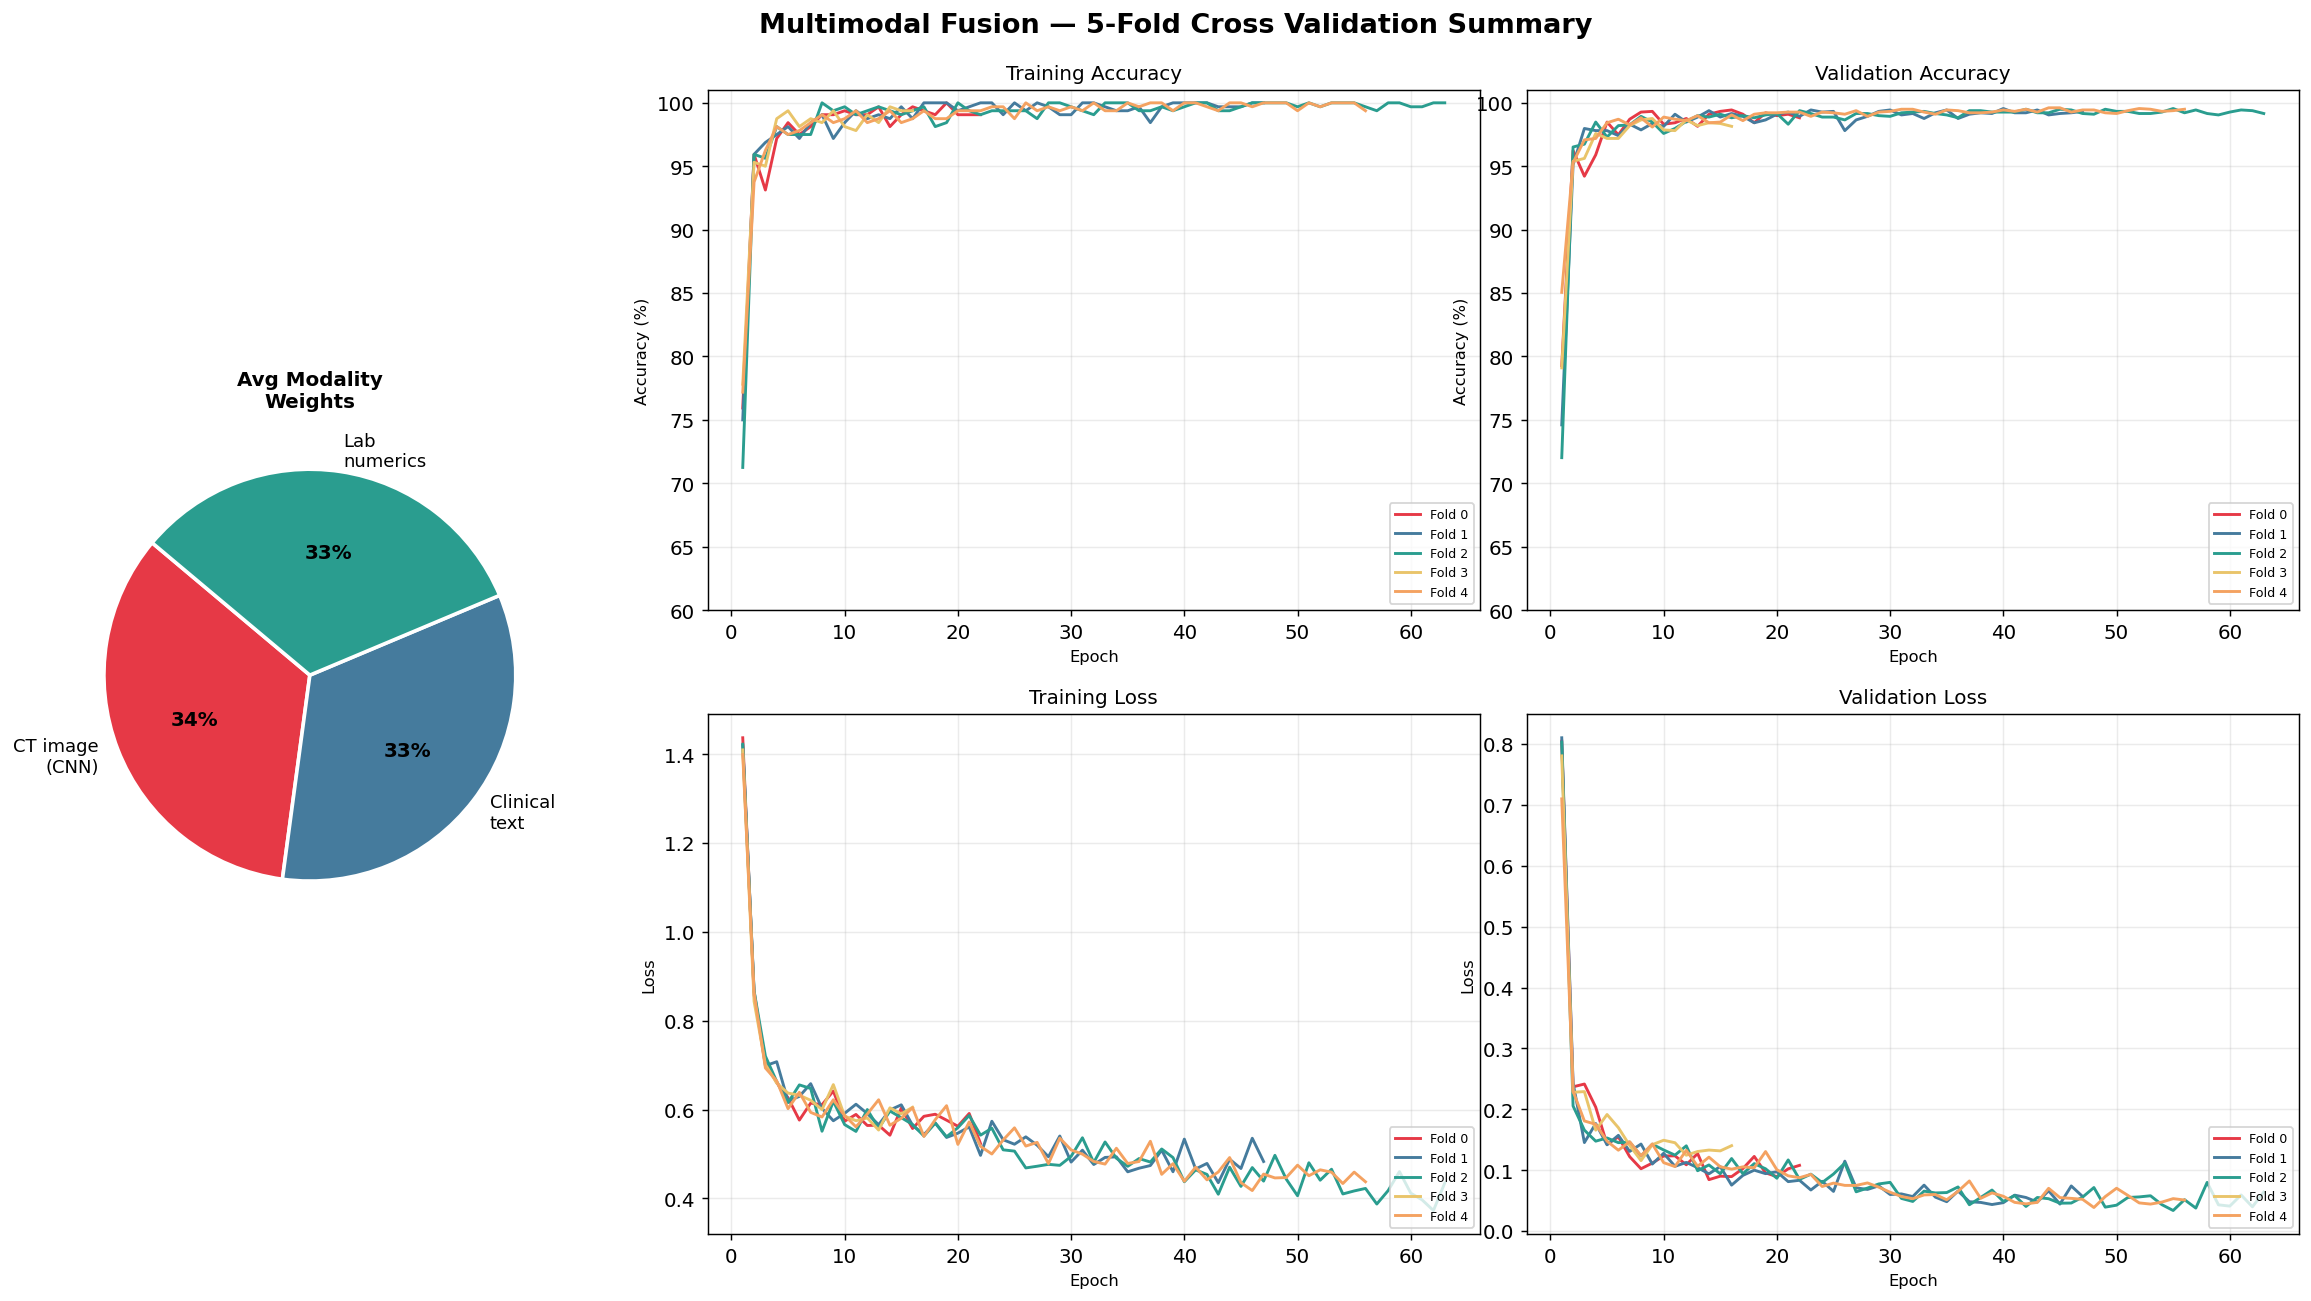

✓ Saved paper_style_summary.png


In [10]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Multimodal Fusion — 5-Fold Cross Validation Summary', fontsize=15, fontweight='bold', y=1.01)

# Left: average modality weight pie
ax_pie = fig.add_axes([0.02, 0.15, 0.22, 0.7])
avg_weights = {
    mod: np.mean([mod_weights[f]['weights'][mod] for f in range(NUM_FOLDS)])
    for mod in modalities
}
wedges, texts, autotexts = ax_pie.pie(
    list(avg_weights.values()),
    labels=['CT image\n(CNN)', 'Clinical\ntext', 'Lab\nnumerics'],
    colors=MODALITY_COLORS,
    autopct='%1.0f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
ax_pie.set_title('Avg Modality\nWeights', fontsize=11, fontweight='bold')

# Right: 2x2 grid of comparison plots
plot_specs = [
    (0.30, 0.55, 0.33, 0.40, 'train_acc', 'Training Accuracy', 'Accuracy (%)', True),
    (0.65, 0.55, 0.33, 0.40, 'val_acc',   'Validation Accuracy', 'Accuracy (%)', True),
    (0.30, 0.07, 0.33, 0.40, 'train_loss','Training Loss',      'Loss',          False),
    (0.65, 0.07, 0.33, 0.40, 'val_loss',  'Validation Loss',    'Loss',          False),
]

for (left, bottom, width, height, key, title, ylabel, pct) in plot_specs:
    ax = fig.add_axes([left, bottom, width, height])
    for fold in range(NUM_FOLDS):
        vals = extract(histories[fold], key)
        ep   = extract(histories[fold], 'epoch')
        if pct: vals = vals * 100
        ax.plot(ep, vals, color=COLORS[fold], lw=1.6, label=f'Fold {fold}')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    if pct: ax.set_ylim(60, 101)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.25)

plt.savefig('paper_style_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved paper_style_summary.png")